In [7]:
#allow for autoreload of packages
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import matplotlib.pyplot as plt
import pandas as pd

import fresh
import recycle
import utils

# IonQ Aria1: analysis of saved runs

This notebook does **not** submit anything to IonQ. It only re-analyses the results of the earlier Aria1 QPU runs (April 2024, 1000 shots, n = 7 repetitions) for the three native-gate plaquette variants:

- Plaquette-1: direct transpilation of the 4 CNOTs
- Plaquette-2: GPI2 / inverse cancellation
- Plaquette-3: GPI2(π)–MS(0,0) commutation and 4×GPI2(π) cancellation

FRESH: P(ancilla = 1) tables. RECYCLE: P(ancilla = 1) for 1..n repetitions.

In [3]:
n = 7

# FRESH

In [9]:
fr_str = {}

fr_str[1] = """
0.043
0.120	0.115
0.138	0.103	0.090
0.075	0.133	0.138	0.170
0.028	0.118	0.090	0.115	0.150
0.035	0.040	0.095	0.123	0.168	0.183
0.035	0.045	0.043	0.093	0.120	0.178	0.220"""

fr_str[2] = """
0.028
0.09	0.078
0.12	0.14	0.13
0.043	0.1	0.09	0.15
0.035	0.098	0.088	0.12	0.17
0.033	0.045	0.088	0.14	0.17	0.19
0.023	0.025	0.003	0.078	0.14	0.15	0.16"""

fr_str[3] = """
0.025
0.078	0.058
0.098	0.045	0.075
0.083	0.11	0.088	0.11
0.018	0.093	0.058	0.1	0.1
0.015	0.02	0.098	0.078	0.08	0.093
0.018	0.013	0.013	0.073	0.095	0.1	0.12"""

fr = {plaq: utils.create_df(s) for plaq, s in fr_str.items()}

Plaquette-1


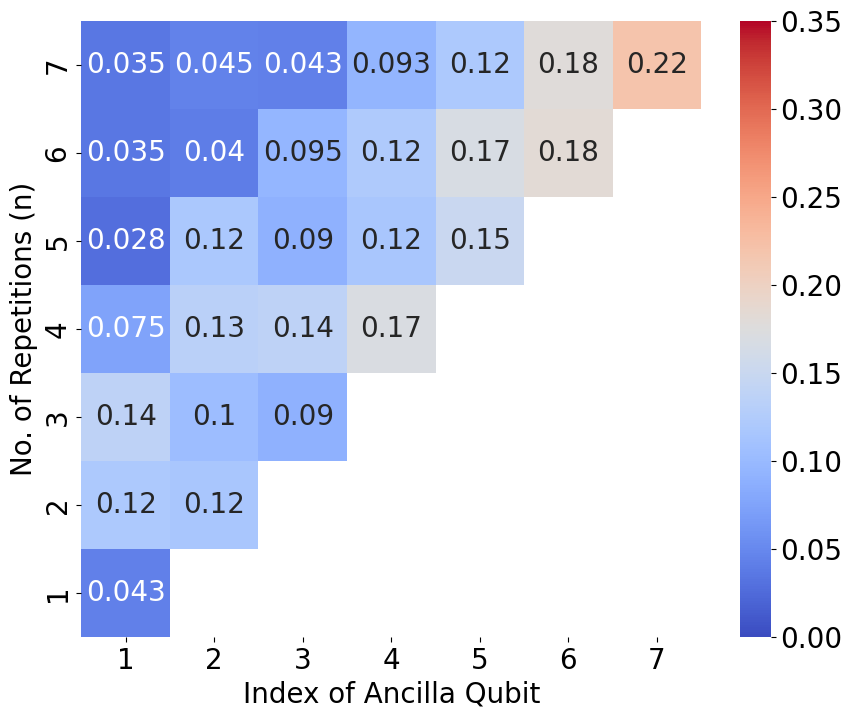

Plaquette-2


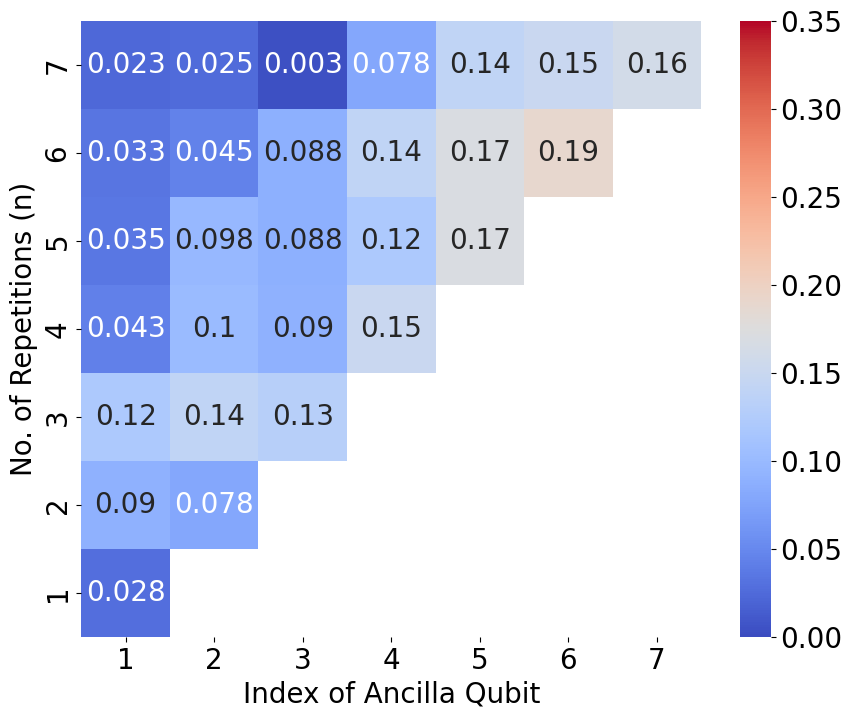

Plaquette-3


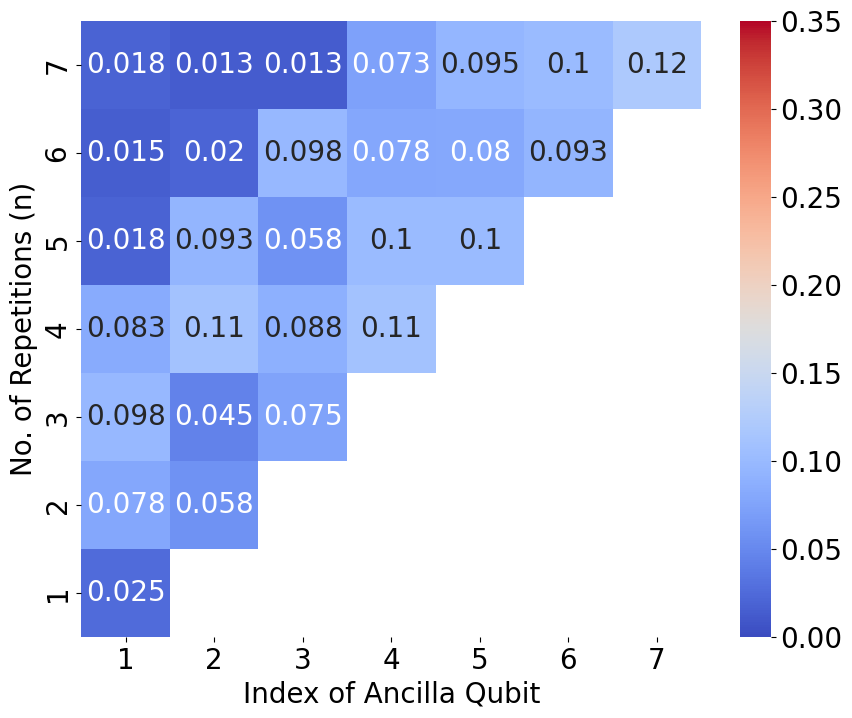

In [10]:
for plaq in fr:
    print(f"Plaquette-{plaq}")
    fresh.plot_heatmap(fr[plaq], plaq)

# RECYCLE

In [11]:
# P(ancilla = 1) for 1..n repetitions
re = {
    1: [0.082, 0.117, 0.195, 0.238, 0.300, 0.322, 0.350],
    2: [0.084, 0.097, 0.145, 0.169, 0.200, 0.229, 0.269],
    3: [0.035, 0.050, 0.085, 0.080, 0.090, 0.115, 0.125],
}

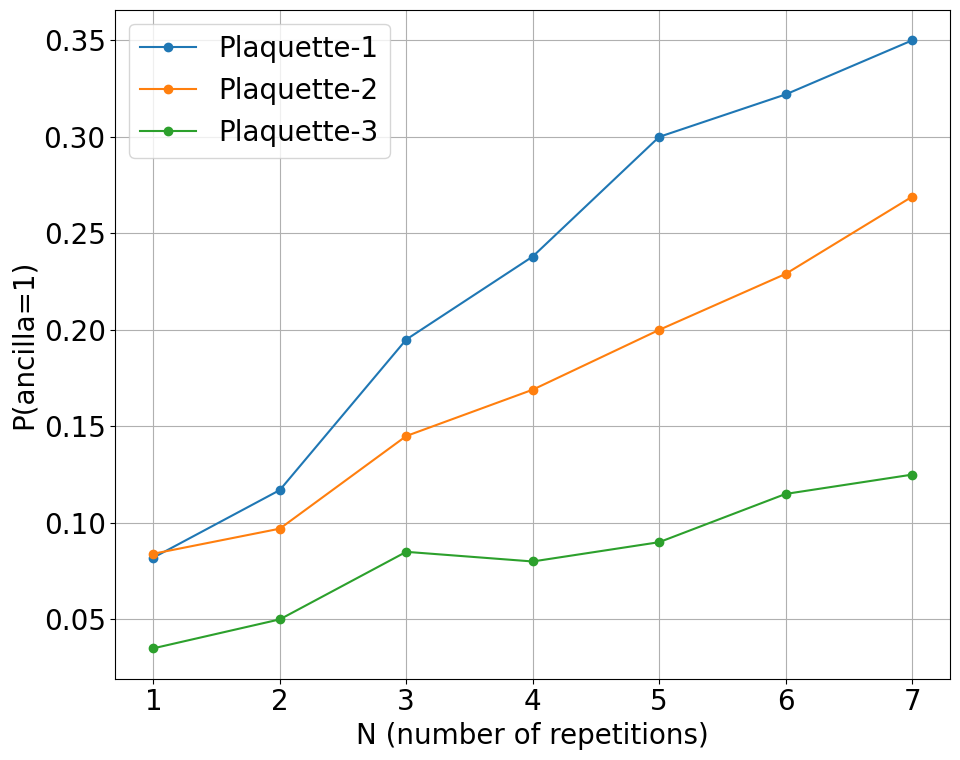

In [12]:
plt.figure(figsize=(10, 8))
for plaq in re:
    plt.plot(range(1, n + 1), re[plaq], marker="o", label=f"Plaquette-{plaq}")
plt.xlabel("N (number of repetitions)")
plt.ylabel("P(ancilla=1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Error rates

In [13]:
rows = []
for plaq in fr:
    corre = recycle.corr_err(fr[plaq], re[plaq], n)                  # Eq. (4)
    rows.append({
        "plaquette": plaq,
        "plaq_F Eq.12 (%)": fresh.plag_error_rate(fr[plaq], n, window=True) * 100,
        "plaq_F Eq.6 (%)": fresh.plag_error_rate(fr[plaq], n, window=False) * 100,
        "plaq_R Eq.8 (%)": recycle.plag_error_rate(corre, re[plaq], n) * 100,
        "corre Eq.4 (%)": corre * 100,
    })

table = pd.DataFrame(rows).set_index("plaquette").round(2)
table

,plaq_F Eq.12 (%),plaq_F Eq.6 (%),plaq_R Eq.8 (%),corre Eq.4 (%)
plaquette,,,,
1,2.45,2.95,1.73,2.74
2,2.44,2.20,1.98,1.10
3,1.30,1.58,1.67,-0.17
